# Quick Start

This notebook runs a small two-channel VAR(2) example and compares the VI warm-start posterior with the NUTS posterior. 

The model fitted here is still the real multivariate pipeline: time-domain data are converted to Wishart frequency-domain statistics, a log-P-spline spectral matrix is fitted, and posterior PSD/coherence summaries are reconstructed from the sampled spline weights.

In [ ]:
! pip install -q LogPSplinePSD

## Imports

In [1]:
import os

os.environ.setdefault("XLA_FLAGS", "--xla_force_host_platform_device_count=1")

import jax
import matplotlib.pyplot as plt
import numpy as np

jax.config.update("jax_enable_x64", True)

from log_psplines.arviz_utils import (
    get_multivar_posterior_psd_quantiles,
    get_multivar_vi_psd_quantiles,
)
from log_psplines.datatypes import MultivariateTimeseries
from log_psplines.mcmc import run_mcmc
from log_psplines.pipeline.config import PipelineConfig
from log_psplines.plotting import PSDMatrixPlotSpec, plot_psd_matrix
from log_psplines.example_datasets import VARMAData

## Simulate a two-channel VAR process

The coefficient matrices below match the VAR3 study used elsewhere in the repository, but this notebook uses a smaller sample size and shorter inference settings.

|03:53| LogPSpline | INFO | VAR sanity check passed: stationary AR dynamics (companion spectral radius=0.707107) with finite samples. Empirical stationarity passed (max_mean_shift_z=0.043, max_var_ratio=1.034, covariance_rel_drift=0.024).


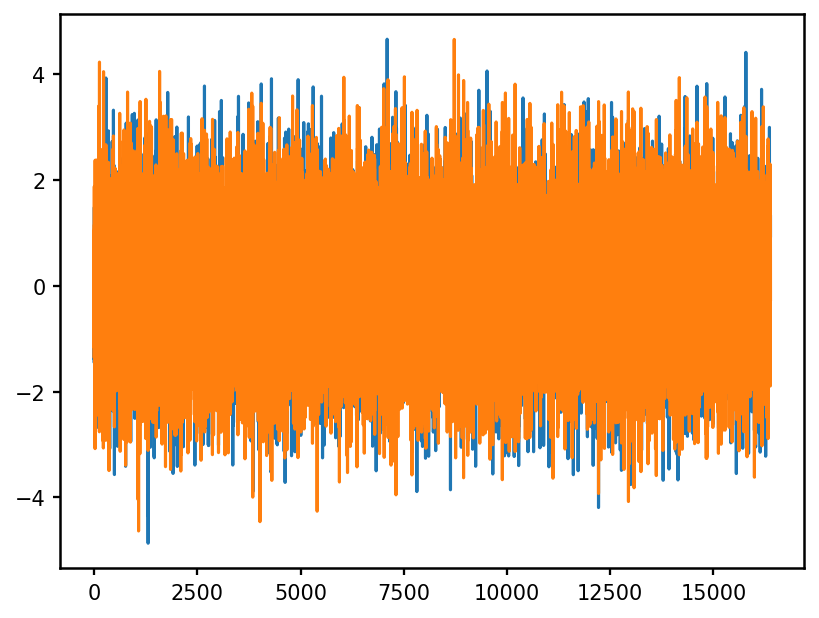

In [ ]:
varma = VARMAData(n_samples=2**14)
plt.plot(varma.data)

## Run VI warm start and NUTS

These settings are small enough for an interactive quickstart. Increase `N`, `n_warmup`, `n_samples`, `vi_steps`, and `n_knots` for a real analysis.

In [ ]:


config = PipelineConfig(
    n_knots=10,
    degree=2,
    diffMatrixOrder=2,
    n_warmup=500,
    n_samples=750,
    num_chains=2,
    init_from_vi=True,
    only_vi=False,
    vi_guide="diag",
    Nb=8,
    target_accept_prob=0.9,
    max_tree_depth=8,
    true_psd=varma.get_true_psd(),
    rng_key=7,
    verbose=True,
)

idata = run_mcmc(varma.ts, config)

|07:23| LogPSpline | INFO | Wishart averaging (blocks=8): n=16384 -> Lb=2048, N=1024, p=2
|07:23| LogPSpline | INFO | Standardized data: scale ~1.35e+00
|07:23| LogPSpline | INFO | Inferred sampler type: multivar_blocked_nuts
|07:25| LogPSpline | INFO | Spline model: MultivariateLogPSplines(channels=2, knots=10, degree=2, penaltyOrder=2, N=1024, basis_shapes=[(1024, 11), (1024, 11), (1024, 11), (1024, 11)])


sample: 100%|██████████| 1250/1250 [00:01<00:00, 761.26it/s, 15 steps of size 3.30e-01. acc. prob=0.93] 


## Compare VI and NUTS posterior PSDs

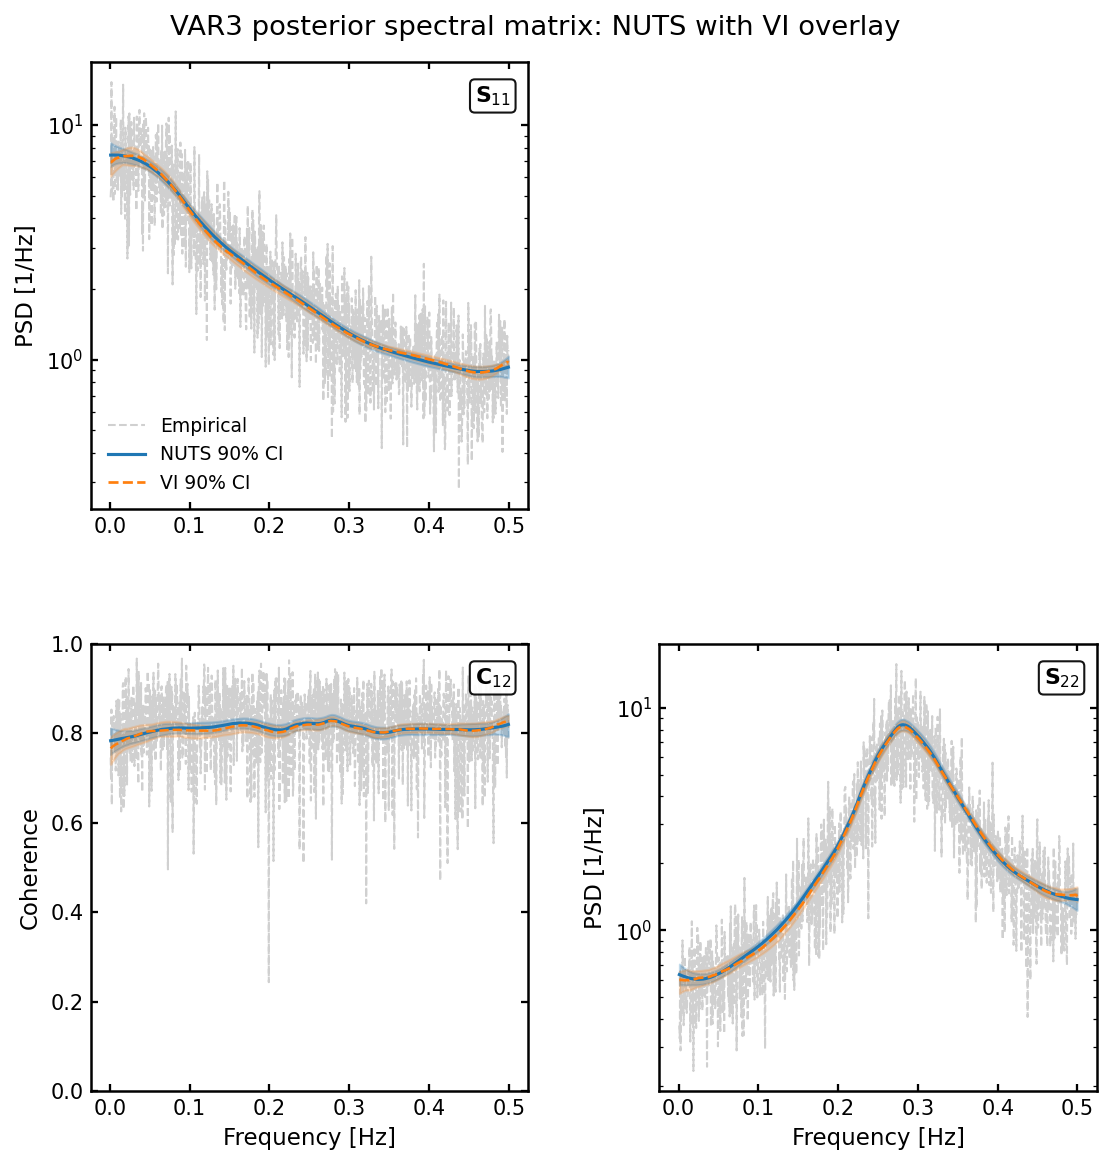

In [27]:
fig, axes = plot_psd_matrix(
    PSDMatrixPlotSpec(
        idata=idata,
        overlay_vi=True,
        label="NUTS 90% CI",
        vi_label="VI 90% CI",
        channel_labels=["x0", "x1", "x2"],
        show_knots=False,
        save=False,
        close=False,
    )
)
fig.suptitle("VAR3 posterior spectral matrix: NUTS with VI overlay", y=1.02)
plt.savefig("_static/var3_psd_matrix.png", bbox_inches="tight")
plt.show()

![](_static/var3_psd_matrix.png)

## What to check

- The diagonal PSD panels should be positive and broadly track the analytical PSD.
- VI and NUTS should have similar large-scale structure; exact agreement is not expected for this very short smoke-test run.
- For production runs, increase the warmup/draw counts and inspect the saved diagnostics from `PipelineConfig(outdir=...)`.